#### Leaky Integrate and Fire Model (Non-Fractional)

In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
class LeakyIntegrateAndFireModel():
    """"
    Non-Fractional Leaky Integrate and Fire Model
    """

    def __init__(self, dt: float, time_constant: float, bias: float = 0.0,
                 threshold_voltage: float = 20.0, reset_voltage: float = 0.0, membrane_resistance: float = 10, refractory: float = 5) -> None:
        self.dt = dt
        self.time_constant = time_constant
        self.bias = bias
        self.threshold_voltage = threshold_voltage
        self.reset_voltage = reset_voltage
        self.voltage = 0
        self.spike_state = False
        self.membrane_resistance = membrane_resistance # Unit: MΩ
        self.spike_times = []
        self.spike_voltages = []
        self.refractory = refractory # Unit: ms

    def update_voltage(self, input_current: float, dt: float, t: float) -> None:
        """
        Equation for V_n+1: V_n + (dt/tau)[-V_n + (bias + Rm*I_n)]

        :return: None
        """
        if self.spike_state:
            self.spike_times.append(t)
            self.spike_voltages.append(self.voltage)
            self.voltage = self.reset_voltage
        elif self.spike_times and (t - self.spike_times[-1] <= self.refractory):
                return
        else:
            self.voltage = self.voltage + (dt/self.time_constant) * (-self.voltage + (self.bias + self.membrane_resistance * input_current))

        self.update_spike_state()

    def update_spike_state(self):
        self.spike_state = self.voltage >= self.threshold_voltage

In [9]:
LIF_model = LeakyIntegrateAndFireModel(0.10, 100)

time = 50 * 1000
frequency = 0.5
I_min, I_max = 5, 15

timestamps = np.arange(0, time, LIF_model.dt)
print(timestamps)
I_app = I_min + (I_max - I_min) * 0.5 * (1+ np.sin(2*np.pi*timestamps*frequency/1000))

I = 2.1
I_app = I * np.ones(len(timestamps))
# Gaussian white noise

voltages = []

for i, t in enumerate(timestamps):
    LIF_model.update_voltage(I_app[i], LIF_model.dt, t)
    voltages.append(LIF_model.voltage)

[0.00000e+00 1.00000e-01 2.00000e-01 ... 4.99997e+04 4.99998e+04
 4.99999e+04]


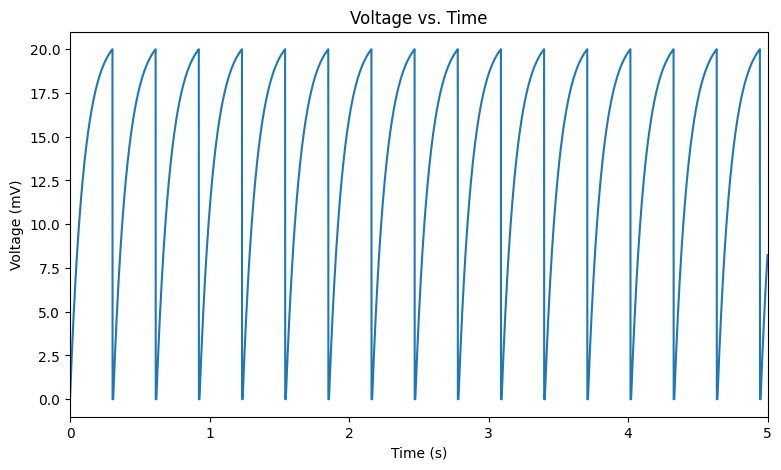

In [10]:
plt.figure(figsize=(9, 5))
plt.ylabel("Voltage (mV)")
plt.xlabel("Time (s)")
plt.title("Voltage vs. Time")
plt.xlim(0, 5)
plt.plot(timestamps/1000, voltages)

(0.0, 4.0)

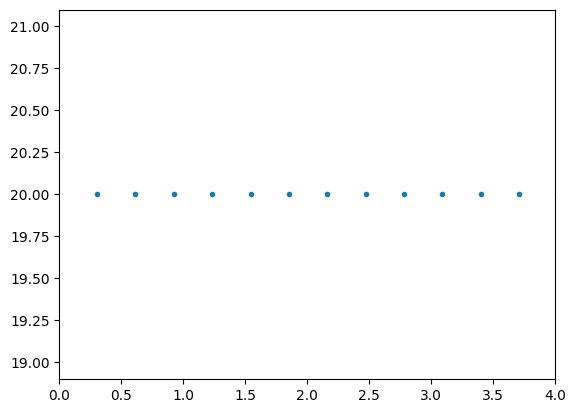

In [11]:
plt.plot(np.asarray(LIF_model.spike_times)/1000, LIF_model.spike_voltages, '.')
plt.xlim(0, 4)

In [12]:
LIF_model.time_constant

100

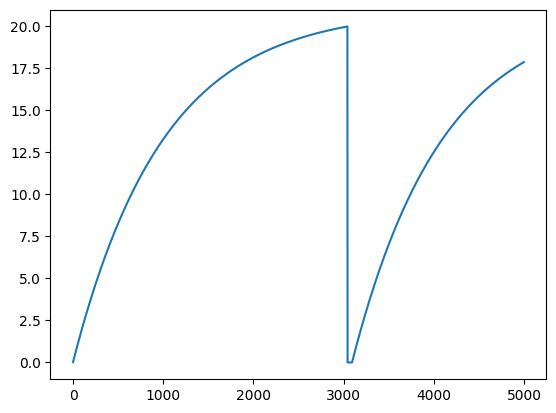

In [15]:
plt.plot(voltages[:5000])